In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
df=pd.read_csv("/content/Seasonal and Annual Mean Temperature Series for the period 1901 to 2021.csv")

In [23]:
df

,YEAR,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC
0,1901,25.42,20.11,27.64,28.16,23.10
1,1902,25.42,20.88,27.96,27.98,22.51
2,1903,25.01,19.99,27.02,28.00,22.33
3,1904,24.93,19.76,27.23,27.57,22.56
4,1905,24.84,18.36,26.38,28.20,23.13
...,...,...,...,...,...,...
116,2017,26.04,21.37,28.20,28.39,23.84
117,2018,25.90,21.24,28.16,28.28,23.55
118,2019,25.86,20.71,28.00,28.60,23.49
119,2020,25.78,20.79,27.58,28.45,23.75


In [21]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   YEAR     121 non-null    int64  
 1   ANNUAL   121 non-null    float64
 2   JAN-FEB  121 non-null    float64
 3   MAR-MAY  121 non-null    float64
 4   JUN-SEP  121 non-null    float64
 5   OCT-DEC  121 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 5.8 KB
None


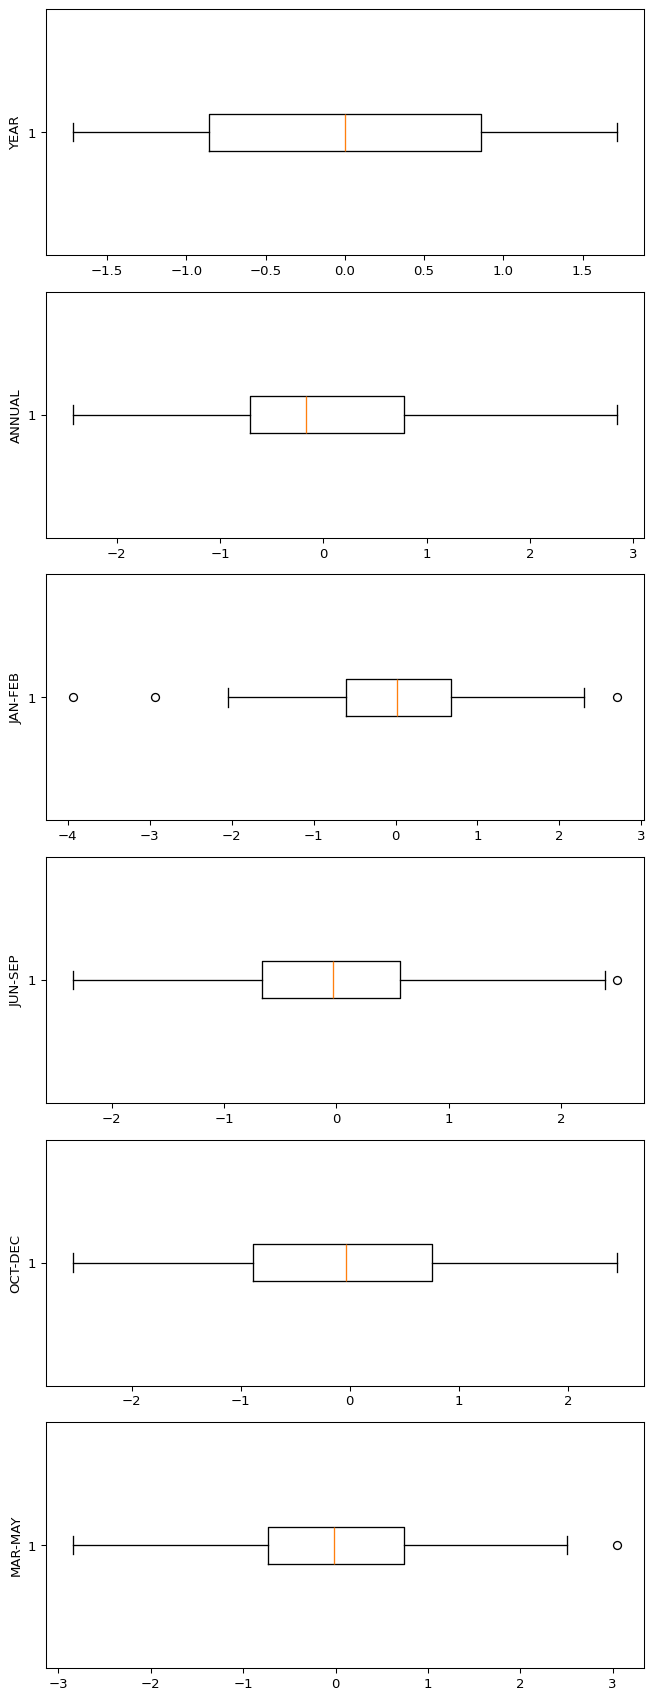

In [34]:
df.describe()

fig, axs = plt.subplots(len(df.columns), 1, figsize=(7, 18), dpi=95)
for i, col in enumerate(df.columns):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

In [24]:
# 1.Load Data

df = pd.read_csv('/content/Seasonal and Annual Mean Temperature Series for the period 1901 to 2021.csv') # Replace with your actual CSV file path
print("Original Data Shape:", df.shape)
print(df.head())

Original Data Shape: (121, 6)
   YEAR  ANNUAL  JAN-FEB  MAR-MAY  JUN-SEP  OCT-DEC
0  1901   25.42    20.11    27.64    28.16    23.10
1  1902   25.42    20.88    27.96    27.98    22.51
2  1903   25.01    19.99    27.02    28.00    22.33
3  1904   24.93    19.76    27.23    27.57    22.56
4  1905   24.84    18.36    26.38    28.20    23.13


In [25]:
# 2.Basic Info

print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())


Data Types:
 YEAR         int64
ANNUAL     float64
JAN-FEB    float64
MAR-MAY    float64
JUN-SEP    float64
OCT-DEC    float64
dtype: object

Missing Values:
 YEAR       0
ANNUAL     0
JAN-FEB    0
MAR-MAY    0
JUN-SEP    0
OCT-DEC    0
dtype: int64


In [27]:
# 3.Handle Missing Values

# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Numerical: Replace with mean
num_imputer = SimpleImputer(strategy='mean')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical: Replace with mode
if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [28]:
#4.Encode Categorical Variables

#Label Encoding (for binary categorical)
le = LabelEncoder()
for col in cat_cols:
  if df[col].nunique() == 2:
    df[col] = le.fit_transform(df[col])

In [29]:
# 5.Outlier Detection and Treatment (using IQR)

for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df[col] = np.where(df[col] < lower, lower, df[col])
df[col] = np.where(df[col] > upper, upper, df[col])

In [30]:
# 6.Feature Scaling

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=10 is greater than n_features=5. All the features will be returned.
  warnings.warn(



Selected Features: ['YEAR', 'ANNUAL', 'JAN-FEB', 'JUN-SEP', 'OCT-DEC']


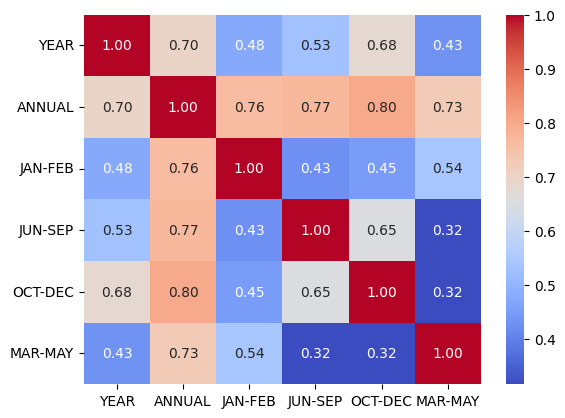

MAR-MAY    1.000000
ANNUAL     0.725303
JAN-FEB    0.538704
YEAR       0.431315
OCT-DEC    0.317685
JUN-SEP    0.315720
Name: MAR-MAY, dtype: float64


In [36]:
from sklearn.feature_selection import SelectKBest, f_regression
target_col = 'MAR-MAY'  # Replace with your actual target column name

if target_col in df.columns:
    X = df.drop(target_col, axis=1)
    y = df[target_col]

    bestfeatures = SelectKBest(score_func=f_regression, k=10)
    fit = bestfeatures.fit(X, y)

    selected_features = X.columns[fit.get_support()]
    df = df[selected_features.to_list() + [target_col]]

    print("\nSelected Features:", selected_features.to_list())

corr = df.corr()
corr.sort_values(by='MAR-MAY', ascending=False)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

print(corr['MAR-MAY'].sort_values(ascending=False))

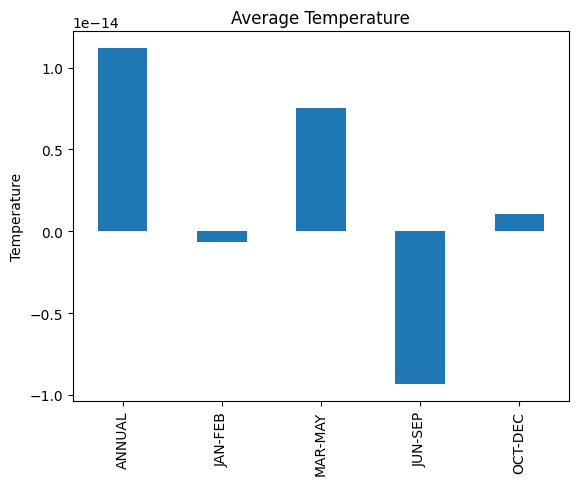

In [53]:
df[['ANNUAL', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC']].mean().plot(kind='bar')

plt.title('Average Temperature')
plt.ylabel('Temperature')
plt.show()

In [54]:
import numpy as np
import sklearn.preprocessing as preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop(columns=['MAR-MAY'])
y = np.asarray(df['MAR-MAY'])

# Scale the features using preprocessing.StandardScaler()
X = preprocessing.StandardScaler().fit(X).transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size = 0.3, random_state = 100)

print ('Train set:', X_train.shape, y_train.shape)
print ('Test set:', X_test.shape, y_test.shape)

Train set: (84, 5) (84,)
Test set: (37, 5) (37,)


In [55]:
#Regression Models
#1.Linear Regression

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import r2_score
print("R² Score:", r2_score(y_test, y_pred))

R² Score: 0.9987876078036737


In [56]:
#2.Decision Tree

from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import r2_score
print("R² Score:", r2_score(y_test, y_pred))

R² Score: 0.08437432235516984


In [57]:
#3.Random Forest
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import r2_score
print("R² Score:", r2_score(y_test, y_pred))

R² Score: 0.6102779195997873


In [58]:
#4.K-Nearest Neighbors

from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=10)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import r2_score
print("R² Score:", r2_score(y_test, y_pred))

R² Score: 0.39555187394899105


In [59]:
#5.Support Vector Regression

from sklearn.svm import SVR
model = SVR()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import r2_score
print("R² Score:", r2_score(y_test, y_pred))

R² Score: 0.7592293008858733


In [60]:
#6.Gradient Boosting

from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import r2_score
print("R² Score:", r2_score(y_test, y_pred))

R² Score: 0.5892832023979505


In [61]:
#7.Ridge Regression

from sklearn.linear_model import Ridge
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import r2_score
print("R² Score:", r2_score(y_test, y_pred))

R² Score: 0.9839210525607146
